<a href="https://colab.research.google.com/github/unharshly-harsh/copd_project/blob/main/COPD_MINI1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving copd_asthma_spirometry_real_patients.csv to copd_asthma_spirometry_real_patients.csv


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import pandas as pd

df = pd.read_csv("copd_asthma_spirometry_real_patients.csv")

df.head()

,Patient_ID,Age,Sex,Smoking_Pack_Years,Cough_Score_0_5,Wheeze_Score_0_5,SpO2_percent,FEV1_FVC_Ratio,FEV1_percent_predicted,Bronchodilator_Response_pct,Eosinophil_Count_cells_uL,AQI_Exposure,Actual_Diagnosis
0,TEST_001,44,M,1.6,1,0,98.3,0.84,92.9,3.7,50,82.5,Healthy
1,TEST_002,24,F,5.3,3,5,99.7,0.70,101.5,23.2,421,231.1,Asthma
2,TEST_003,59,F,0.0,1,0,99.5,0.77,89.3,2.8,245,112.7,Healthy
3,TEST_004,47,M,2.7,0,0,97.7,0.84,104.2,1.0,281,126.3,Healthy
4,TEST_005,75,M,39.9,3,2,90.8,0.59,47.6,2.5,90,114.9,COPD


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Patient_ID                   100 non-null    object 
 1   Age                          100 non-null    int64  
 2   Sex                          100 non-null    object 
 3   Smoking_Pack_Years           100 non-null    float64
 4   Cough_Score_0_5              100 non-null    int64  
 5   Wheeze_Score_0_5             100 non-null    int64  
 6   SpO2_percent                 100 non-null    float64
 7   FEV1_FVC_Ratio               100 non-null    float64
 8   FEV1_percent_predicted       100 non-null    float64
 9   Bronchodilator_Response_pct  100 non-null    float64
 10  Eosinophil_Count_cells_uL    100 non-null    int64  
 11  AQI_Exposure                 100 non-null    float64
 12  Actual_Diagnosis             100 non-null    object 
dtypes: float64(6), int64(

In [ ]:
df.describe()

,Age,Smoking_Pack_Years,Cough_Score_0_5,Wheeze_Score_0_5,SpO2_percent,FEV1_FVC_Ratio,FEV1_percent_predicted,Bronchodilator_Response_pct,Eosinophil_Count_cells_uL,AQI_Exposure
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,47.860000,11.159000,2.380000,2.290000,95.116000,0.683600,73.081000,10.308000,291.210000,147.368000
std,18.623337,13.129203,1.650099,1.713258,3.687564,0.127061,22.958274,8.322947,149.517898,62.845448
min,13.000000,0.000000,0.000000,0.000000,86.000000,0.400000,25.700000,0.000000,50.000000,47.400000
25%,31.750000,1.600000,1.000000,1.000000,92.600000,0.590000,53.900000,3.775000,179.750000,99.650000
50%,48.000000,5.100000,3.000000,2.000000,96.150000,0.705000,73.600000,8.000000,270.000000,143.600000
75%,61.000000,17.675000,4.000000,4.000000,97.825000,0.800000,93.000000,14.425000,380.750000,206.950000
max,83.000000,52.600000,5.000000,5.000000,100.000000,0.920000,115.000000,36.000000,760.000000,258.400000


In [ ]:
df.columns

Index(['Patient_ID', 'Age', 'Sex', 'Smoking_Pack_Years', 'Cough_Score_0_5',
       'Wheeze_Score_0_5', 'SpO2_percent', 'FEV1_FVC_Ratio',
       'FEV1_percent_predicted', 'Bronchodilator_Response_pct',
       'Eosinophil_Count_cells_uL', 'AQI_Exposure', 'Actual_Diagnosis'],
      dtype='object')

In [ ]:
df.isnull().sum()

,0
Patient_ID,0
Age,0
Sex,0
Smoking_Pack_Years,0
Cough_Score_0_5,0
Wheeze_Score_0_5,0
SpO2_percent,0
FEV1_FVC_Ratio,0
FEV1_percent_predicted,0
Bronchodilator_Response_pct,0


In [ ]:
df.columns

Index(['Patient_ID', 'Age', 'Sex', 'Smoking_Pack_Years', 'Cough_Score_0_5',
       'Wheeze_Score_0_5', 'SpO2_percent', 'FEV1_FVC_Ratio',
       'FEV1_percent_predicted', 'Bronchodilator_Response_pct',
       'Eosinophil_Count_cells_uL', 'AQI_Exposure', 'Actual_Diagnosis'],
      dtype='object')

In [ ]:
df.head()

,Patient_ID,Age,Sex,Smoking_Pack_Years,Cough_Score_0_5,Wheeze_Score_0_5,SpO2_percent,FEV1_FVC_Ratio,FEV1_percent_predicted,Bronchodilator_Response_pct,Eosinophil_Count_cells_uL,AQI_Exposure,Actual_Diagnosis
0,TEST_001,44,M,1.6,1,0,98.3,0.84,92.9,3.7,50,82.5,Healthy
1,TEST_002,24,F,5.3,3,5,99.7,0.70,101.5,23.2,421,231.1,Asthma
2,TEST_003,59,F,0.0,1,0,99.5,0.77,89.3,2.8,245,112.7,Healthy
3,TEST_004,47,M,2.7,0,0,97.7,0.84,104.2,1.0,281,126.3,Healthy
4,TEST_005,75,M,39.9,3,2,90.8,0.59,47.6,2.5,90,114.9,COPD


In [ ]:
X = df.drop(["Patient_ID", "Actual_Diagnosis"], axis=1)
y = df["Actual_Diagnosis"]

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

In [ ]:
X = pd.get_dummies(X, drop_first=True)

In [ ]:
print(X.shape)
print(X.head())

(100, 11)
   Age  Smoking_Pack_Years  Cough_Score_0_5  Wheeze_Score_0_5  SpO2_percent  \
0   44                 1.6                1                 0          98.3   
1   24                 5.3                3                 5          99.7   
2   59                 0.0                1                 0          99.5   
3   47                 2.7                0                 0          97.7   
4   75                39.9                3                 2          90.8   

   FEV1_FVC_Ratio  FEV1_percent_predicted  Bronchodilator_Response_pct  \
0            0.84                    92.9                          3.7   
1            0.70                   101.5                         23.2   
2            0.77                    89.3                          2.8   
3            0.84                   104.2                          1.0   
4            0.59                    47.6                          2.5   

   Eosinophil_Count_cells_uL  AQI_Exposure  Sex_M  
0                 

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25,random_state=42,stratify=y)
print(X_train.shape)
print(X_test.shape)

(75, 11)
(25, 11)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr, average='weighted'))

Accuracy: 1.0
F1 Score: 1.0


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf, average='weighted'))

Accuracy: 1.0
F1 Score: 1.0


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("F1 Score:", f1_score(y_test, y_pred_knn, average='weighted'))

Accuracy: 0.96
F1 Score: 0.959719298245614


In [ ]:
from sklearn.svm import SVC

svm = SVC(probability=True)

svm.fit(X_train_scaled, y_train)

y_pred_svm = svm.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("F1 Score:", f1_score(y_test, y_pred_svm, average='weighted'))

Accuracy: 1.0
F1 Score: 1.0


In [ ]:
from sklearn.metrics import roc_auc_score

# Logistic Regression
roc_lr = roc_auc_score(
    y_test,
    lr.predict_proba(X_test_scaled),
    multi_class='ovr'
)

# Random Forest
roc_rf = roc_auc_score(
    y_test,
    rf.predict_proba(X_test),
    multi_class='ovr'
)

# KNN
roc_knn = roc_auc_score(
    y_test,
    knn.predict_proba(X_test_scaled),
    multi_class='ovr'
)

# SVM
roc_svm = roc_auc_score(
    y_test,
    svm.predict_proba(X_test_scaled),
    multi_class='ovr'
)

print("Logistic Regression ROC-AUC:", roc_lr)
print("Random Forest ROC-AUC:", roc_rf)
print("KNN ROC-AUC:", roc_knn)
print("SVM ROC-AUC:", roc_svm)

Logistic Regression ROC-AUC: 1.0
Random Forest ROC-AUC: 1.0
KNN ROC-AUC: 1.0
SVM ROC-AUC: 1.0


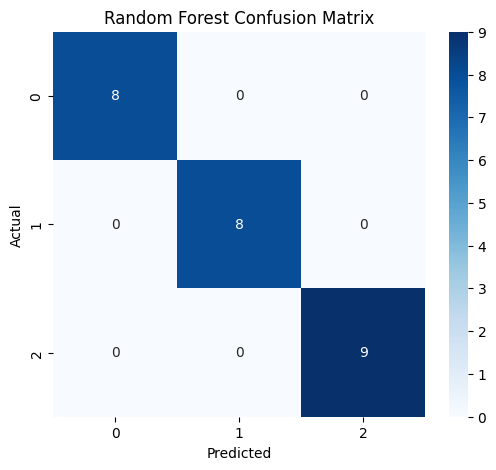

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

In [ ]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "KNN",
        "SVM"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_svm)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lr, average='weighted'),
        f1_score(y_test, y_pred_rf, average='weighted'),
        f1_score(y_test, y_pred_knn, average='weighted'),
        f1_score(y_test, y_pred_svm, average='weighted')
    ]
})

print(results)

                 Model  Accuracy  F1 Score
0  Logistic Regression      1.00  1.000000
1        Random Forest      1.00  1.000000
2                  KNN      0.96  0.959719
3                  SVM      1.00  1.000000


In [ ]:
print("ROC-AUC LR :", roc_lr)
print("ROC-AUC RF :", roc_rf)
print("ROC-AUC KNN:", roc_knn)
print("ROC-AUC SVM:", roc_svm)

ROC-AUC LR : 1.0
ROC-AUC RF : 1.0
ROC-AUC KNN: 1.0
ROC-AUC SVM: 1.0


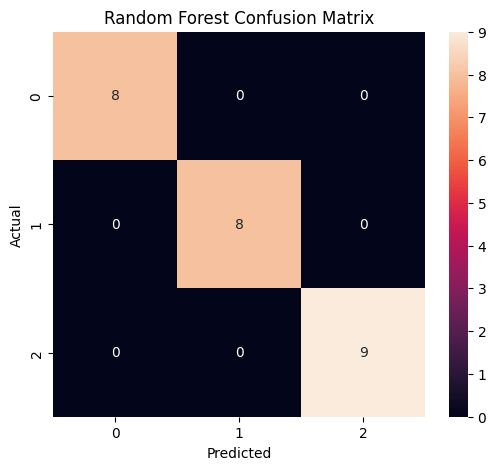

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(10))

                       Feature  Importance
7  Bronchodilator_Response_pct    0.198821
1           Smoking_Pack_Years    0.191957
2              Cough_Score_0_5    0.139183
6       FEV1_percent_predicted    0.115093
3             Wheeze_Score_0_5    0.110354
4                 SpO2_percent    0.093320
5               FEV1_FVC_Ratio    0.065286
8    Eosinophil_Count_cells_uL    0.045243
0                          Age    0.034974
9                 AQI_Exposure    0.004547


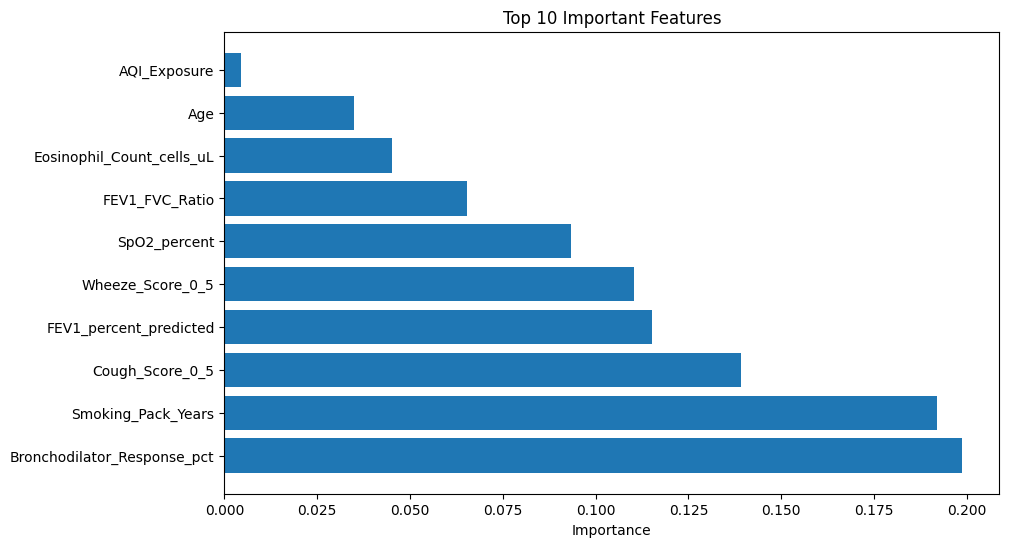

In [ ]:
plt.figure(figsize=(10,6))

plt.barh(
    importance['Feature'][:10],
    importance['Importance'][:10]
)

plt.xlabel("Importance")
plt.title("Top 10 Important Features")

plt.show()

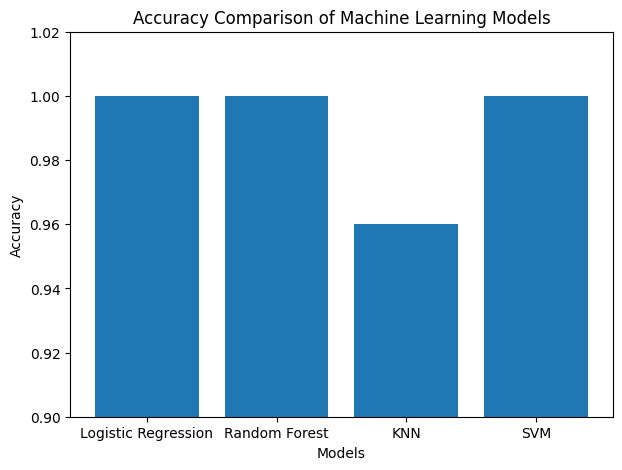

In [ ]:
import matplotlib.pyplot as plt

models = ["Logistic Regression", "Random Forest", "KNN", "SVM"]
accuracy = [1.00, 1.00, 0.96, 1.00]

plt.figure(figsize=(7,5))
plt.bar(models, accuracy)

plt.ylabel("Accuracy")
plt.xlabel("Models")
plt.title("Accuracy Comparison of Machine Learning Models")
plt.ylim(0.90, 1.02)

plt.savefig("accuracy_comparison.png", dpi=300, bbox_inches="tight")
plt.show()